# 04 - Segmentazione clienti con clustering

In questo notebook affrontiamo un problema di **customer segmentation** con algoritmi di clustering.

Domande guida:

- Quanti segmenti naturali di clienti esistono nei dati?
- Quali caratteristiche definiscono ciascun segmento?
- Quali strategie marketing si adattano a ogni gruppo?

Metriche di successo:

- Silhouette Score > 0.40
- Calinski-Harabasz score: piu' alto e' meglio
- Davies-Bouldin score: piu' basso e' meglio
- Interpretabilita' concreta in ottica business

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
ROOT = Path.cwd()
DATA_PATH = ROOT / "Mall_Customers.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = [column.strip() for column in df.columns]
df["Gender_encoded"] = df["Gender"].map({"Male": 1, "Female": 0})

print("Shape:", df.shape)
display(df.head())
display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_values": df.isna().sum(),
            "n_unique": df.nunique(dropna=False),
        }
    )
)

Shape: (200, 6)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


,dtype,missing_values,n_unique
CustomerID,int64,0,200
Gender,str,0,2
Age,int64,0,51
Annual Income (k$),int64,0,64
Spending Score (1-100),int64,0,84
Gender_encoded,int64,0,2


## 1. EDA

Analizziamo:

- istogrammi di Age, Annual Income e Spending Score
- pairplot
- scatter plot Income vs Spending Score
- analisi per gender

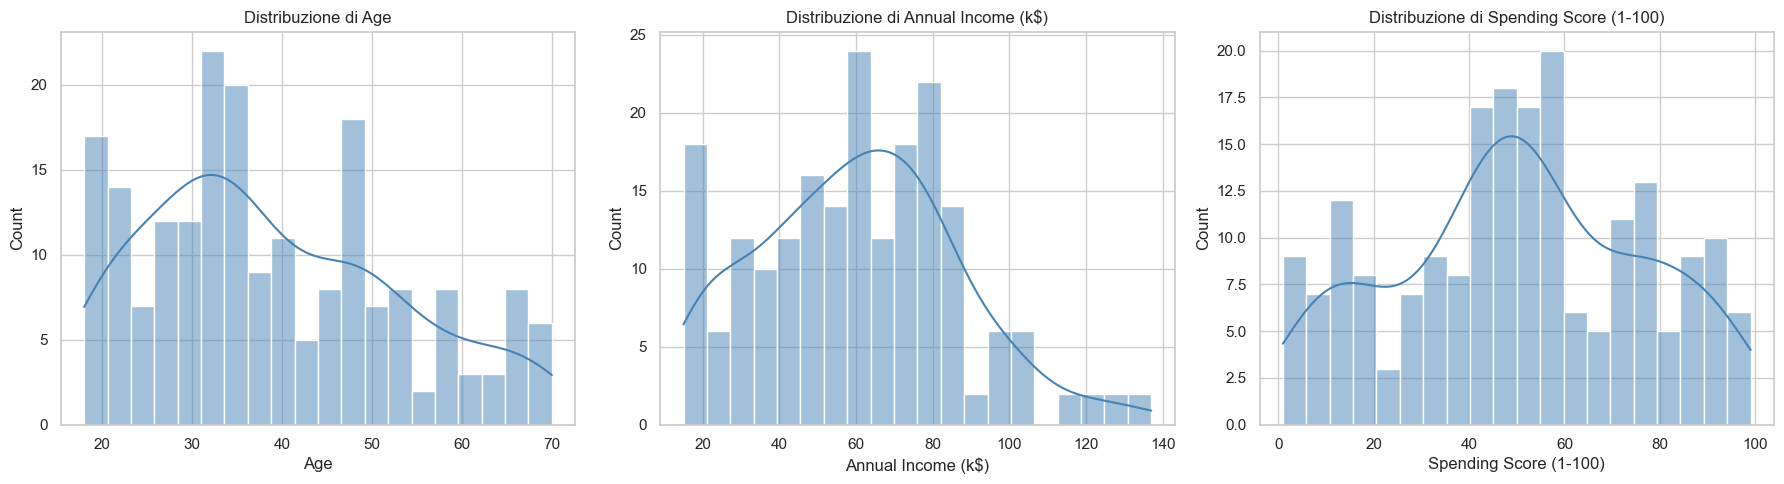

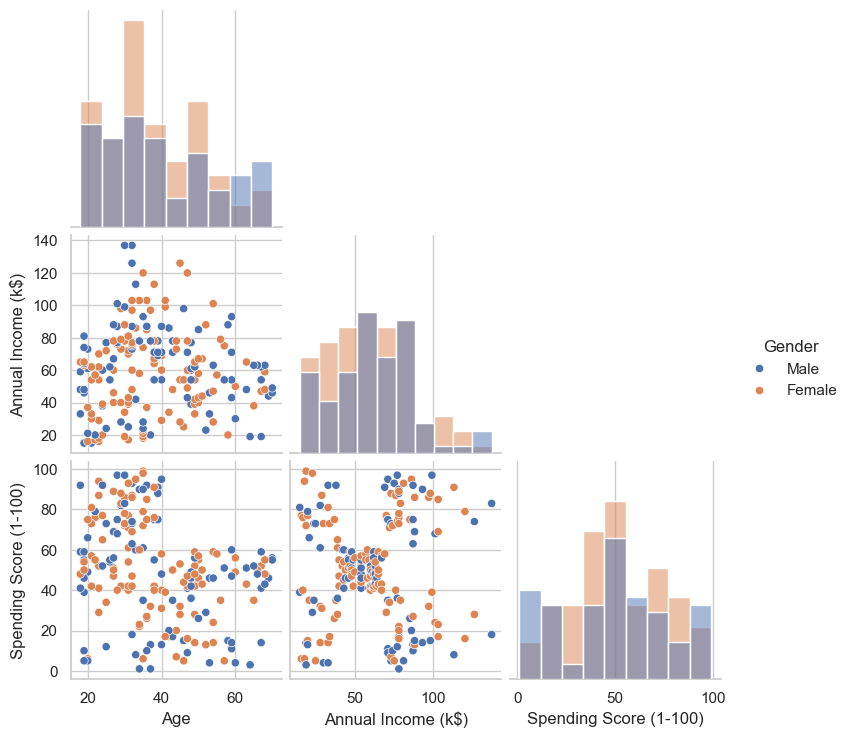

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hist_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for ax, feature in zip(axes, hist_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribuzione di {feature}")
plt.tight_layout()
plt.show()

sns.pairplot(
    df[["Gender", "Age", "Annual Income (k$)"]],
    hue="Gender",
    corner=True,
    diag_kind="hist",
)
plt.show()

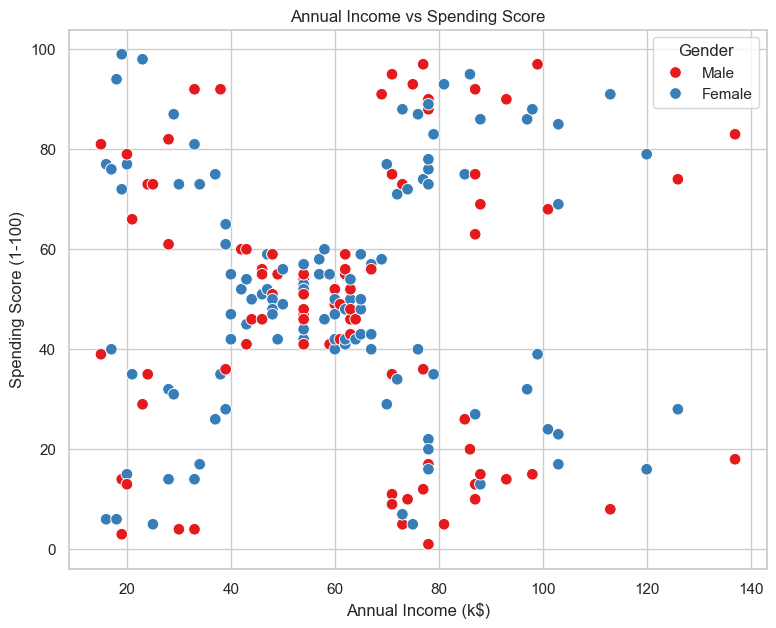

Age        Annual Income (k$)        Spending Score (1-100)  \
             mean median               mean median                   mean   
Gender                                                                      
Female  38.098214   35.0          59.250000   60.0              51.526786   
Male    39.806818   37.0          62.227273   62.5              48.511364   

               
       median  
Gender         
Female   50.0  
Male     50.0

In [4]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    palette="Set1",
    s=70,
)
plt.title("Annual Income vs Spending Score")
plt.show()

gender_summary = df.groupby("Gender").agg(
    {
        "Age": ["mean", "median"],
        "Annual Income (k$)": ["mean", "median"],
        "Spending Score (1-100)": ["mean", "median"],
    }
)
display(gender_summary)

## 2. Preprocessing

In clustering conviene scegliere poche feature ben leggibili.

Scelta metodologica:

- testiamo sia `Income + Spending Score`
- sia `Age + Income + Spending Score`
- codifichiamo anche `Gender` per mostrare come si potrebbe includere

Il modello finale usera' il sottoinsieme che produce segmenti piu' separati e piu' interpretabili.

In [5]:
feature_sets = {
    "income_spending": ["Annual Income (k$)", "Spending Score (1-100)"],
    "age_income_spending": ["Age", "Annual Income (k$)", "Spending Score (1-100)"],
}

feature_set_rows = []
for feature_set_name, feature_columns in feature_sets.items():
    X = df[feature_columns].copy()
    X_scaled = StandardScaler().fit_transform(X)

    best_k = None
    best_silhouette = -1
    for k in range(2, 11):
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        if sil > best_silhouette:
            best_silhouette = sil
            best_k = k

    feature_set_rows.append(
        {
            "feature_set": feature_set_name,
            "features": ", ".join(feature_columns),
            "best_k_by_silhouette": best_k,
            "best_silhouette": best_silhouette,
        }
    )

feature_set_comparison = pd.DataFrame(feature_set_rows).sort_values(
    "best_silhouette", ascending=False
)
display(feature_set_comparison.style.format({"best_silhouette": "{:.4f}"}))

final_feature_columns = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()
X_final = df[final_feature_columns].copy()
X_final_scaled = scaler.fit_transform(X_final)

,feature_set,features,best_k_by_silhouette,best_silhouette
0,income_spending,"Annual Income (k$), Spending Score (1-100)",5,0.5547
1,age_income_spending,"Age, Annual Income (k$), Spending Score (1-100)",6,0.4274


## 3. Numero ottimale di cluster

Usiamo:

- Elbow Method su `k = 2 ... 10`
- Silhouette Analysis su `k = 2 ... 10`
- Silhouette plot per il valore ottimale

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2.0000,269.6910,0.3213,95.6694,1.2670
1,3.0000,157.7040,0.4666,151.3351,0.7165
2,4.0000,108.9213,0.4939,174.5952,0.7096
3,5.0000,65.5684,0.5547,248.6493,0.5722
4,6.0000,55.0573,0.5399,243.0879,0.6546
5,7.0000,44.8648,0.5281,254.6212,0.7148
6,8.0000,37.1481,0.4567,267.9142,0.7579
7,9.0000,32.3923,0.4571,270.9484,0.7632
8,10.0000,29.6858,0.4362,263.3497,0.7645


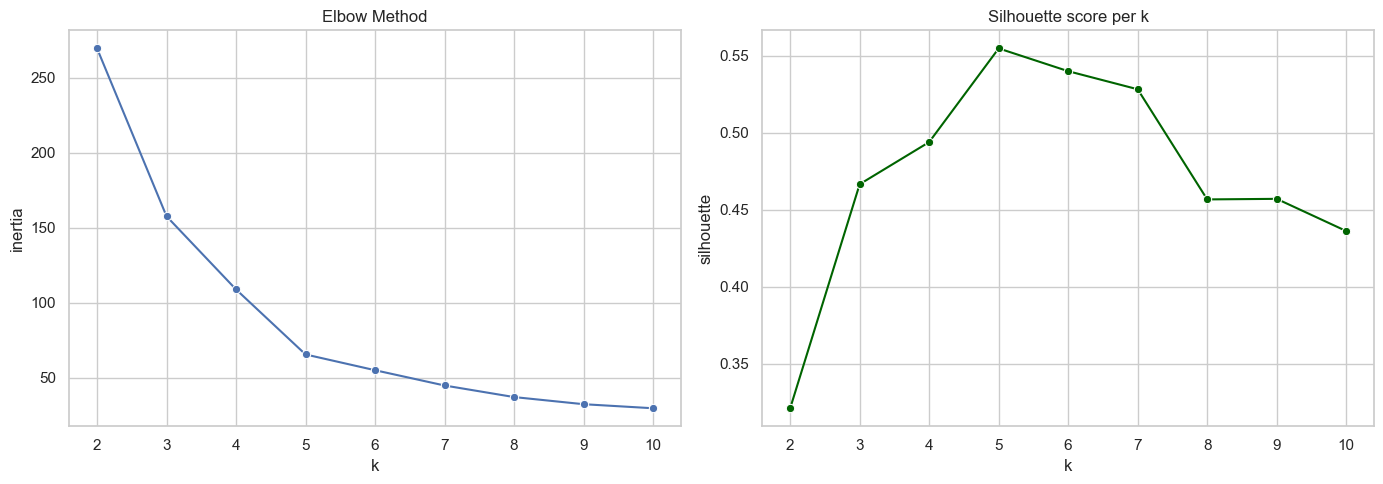

Numero ottimale di cluster scelto: 5


In [6]:
k_rows = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(X_final_scaled)
    k_rows.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X_final_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_final_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_final_scaled, labels),
        }
    )

k_results = pd.DataFrame(k_rows)
display(k_results.style.format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=k_results, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
sns.lineplot(data=k_results, x="k", y="silhouette", marker="o", ax=axes[1], color="darkgreen")
axes[1].set_title("Silhouette score per k")
plt.tight_layout()
plt.show()

optimal_k = int(k_results.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Numero ottimale di cluster scelto:", optimal_k)

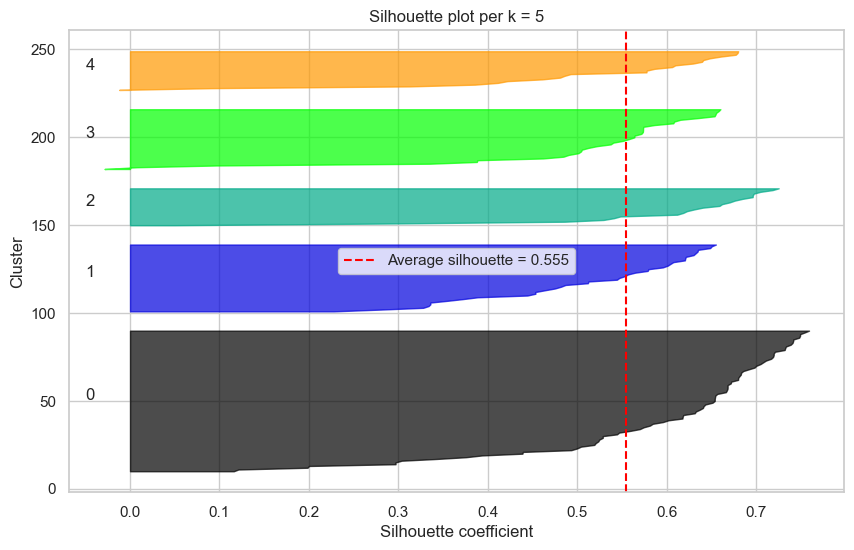

In [7]:
silhouette_kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
silhouette_labels = silhouette_kmeans.fit_predict(X_final_scaled)
sample_silhouette_values = silhouette_samples(X_final_scaled, silhouette_labels)
silhouette_avg = silhouette_score(X_final_scaled, silhouette_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for cluster_id in range(optimal_k):
    cluster_silhouette_values = sample_silhouette_values[silhouette_labels == cluster_id]
    cluster_silhouette_values.sort()
    size_cluster = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster
    color = plt.cm.nipy_spectral(float(cluster_id) / optimal_k)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Average silhouette = {silhouette_avg:.3f}")
ax.set_title(f"Silhouette plot per k = {optimal_k}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.show()

## 4. Modellazione

Confrontiamo almeno tre algoritmi:

- KMeans come baseline
- AgglomerativeClustering con dendrogramma
- DBSCAN con k-distance plot per scegliere `eps`

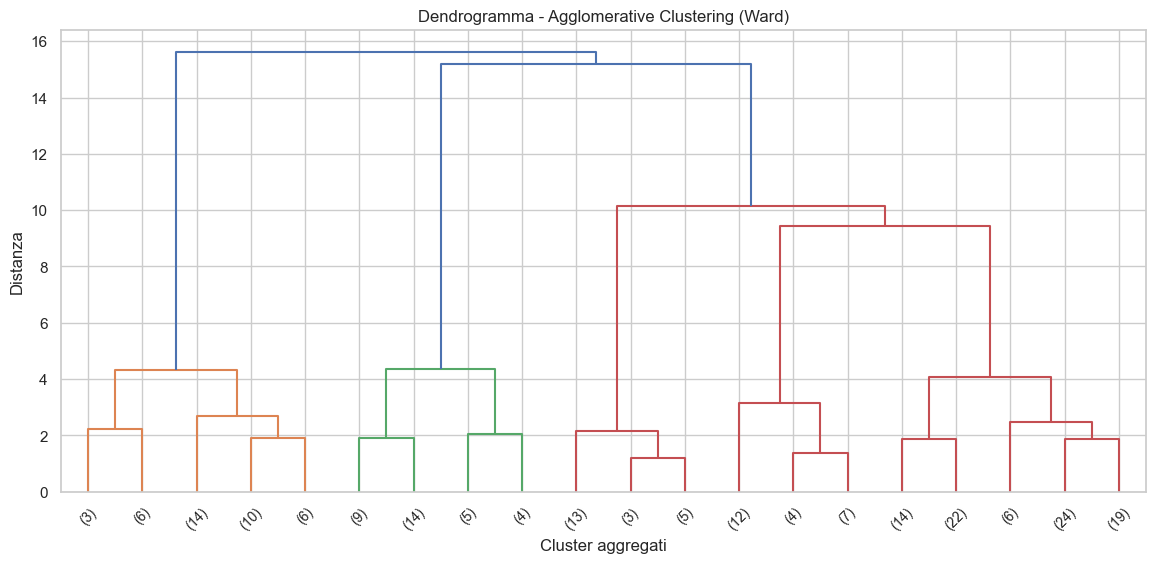

In [8]:
kmeans_model = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans_model.fit_predict(X_final_scaled)

linkage_matrix = linkage(X_final_scaled, method="ward")
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrogramma - Agglomerative Clustering (Ward)")
plt.xlabel("Cluster aggregati")
plt.ylabel("Distanza")
plt.show()

agglomerative_model = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
agglomerative_labels = agglomerative_model.fit_predict(X_final_scaled)

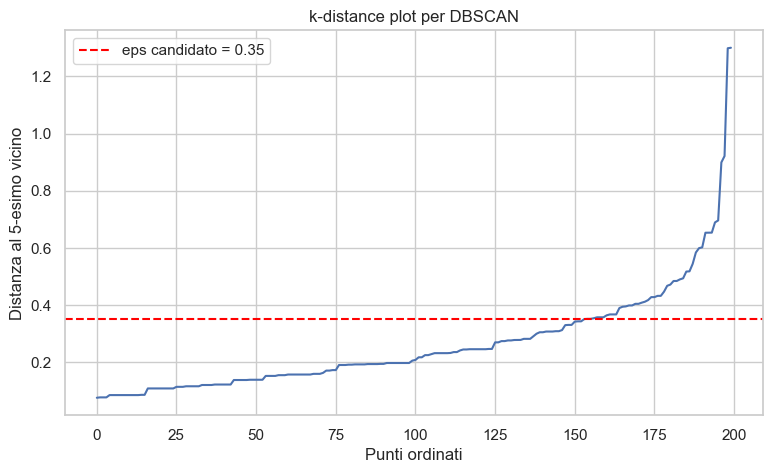

In [9]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_final_scaled)
distances, indices = neighbors.kneighbors(X_final_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title("k-distance plot per DBSCAN")
plt.xlabel("Punti ordinati")
plt.ylabel(f"Distanza al {min_samples}-esimo vicino")
plt.axhline(y=0.35, color="red", linestyle="--", label="eps candidato = 0.35")
plt.legend()
plt.show()

dbscan_eps = 0.35
dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X_final_scaled)

In [10]:
def evaluate_clustering(X_scaled, labels, algorithm_name, ignore_noise=False):
    labels = np.asarray(labels)
    if ignore_noise and (-1 in labels):
        mask = labels != -1
        X_eval = X_scaled[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_scaled
        labels_eval = labels

    unique_clusters = set(labels_eval)
    if len(unique_clusters) < 2:
        return {
            "algorithm": algorithm_name,
            "n_clusters": len(unique_clusters),
            "noise_points": int((labels == -1).sum()),
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    return {
        "algorithm": algorithm_name,
        "n_clusters": len(unique_clusters) - (1 if -1 in unique_clusters else 0),
        "noise_points": int((labels == -1).sum()),
        "silhouette": silhouette_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
    }

model_comparison = pd.DataFrame(
    [
        evaluate_clustering(X_final_scaled, kmeans_labels, "KMeans"),
        evaluate_clustering(X_final_scaled, agglomerative_labels, "Agglomerative"),
        evaluate_clustering(X_final_scaled, dbscan_labels, "DBSCAN", ignore_noise=True),
    ]
)
display(model_comparison.style.format("{:.4f}"))

ValueError: Unknown format code 'f' for object of type 'str'

## 5. Evaluation e interpretazione business

Scegliamo **KMeans** come modello finale perche':

- ottiene metriche eccellenti
- segmenta tutti i clienti
- rende semplice l'assegnazione di nuovi clienti al cluster piu' vicino

Ora profiliamo i cluster e traduciamo i risultati in azioni marketing.

In [11]:
final_model = kmeans_model
final_labels = kmeans_labels

cluster_centers_original = scaler.inverse_transform(final_model.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=final_feature_columns)
centers_df["cluster"] = range(optimal_k)
display(centers_df.sort_values("cluster"))

clustered_df = df.copy()
clustered_df["cluster"] = final_labels

profile_df = clustered_df.groupby("cluster").agg(
    {
        "Age": ["mean", "median"],
        "Annual Income (k$)": ["mean", "median"],
        "Spending Score (1-100)": ["mean", "median"],
        "CustomerID": "count",
    }
)
display(profile_df)

gender_by_cluster = pd.crosstab(
    clustered_df["cluster"], clustered_df["Gender"], normalize="index"
).round(3)
display(gender_by_cluster)

,Annual Income (k$),Spending Score (1-100),cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


Age        Annual Income (k$)        Spending Score (1-100)  \
              mean median               mean median                   mean   
cluster                                                                      
0        42.716049   46.0          55.296296   54.0              49.518519   
1        32.692308   32.0          86.538462   79.0              82.128205   
2        25.272727   23.5          25.727273   24.5              79.363636   
3        41.114286   42.0          88.200000   85.0              17.114286   
4        45.217391   46.0          26.304348   25.0              20.913043   

               CustomerID  
        median      count  
cluster                    
0         50.0         81  
1         83.0         39  
2         77.0         22  
3         16.0         35  
4         17.0         23

Gender,Female,Male
cluster,,
0,0.593,0.407
1,0.538,0.462
2,0.591,0.409
3,0.457,0.543
4,0.609,0.391


In [12]:
def assign_segment_name(income, spending):
    if income >= 70 and spending >= 60:
        return "Premium High Spenders"
    if income >= 70 and spending < 40:
        return "Affluent Selective Customers"
    if income < 40 and spending >= 60:
        return "Budget High Spenders"
    if income < 40 and spending < 40:
        return "Budget Cautious Customers"
    return "Mainstream Balanced Customers"

segment_name_map = {
    int(row["cluster"]): assign_segment_name(
        row["Annual Income (k$)"], row["Spending Score (1-100)"]
    )
    for _, row in centers_df.iterrows()
}

marketing_strategy_map = {
    "Premium High Spenders": "VIP programs, early access to launches, premium upselling, concierge-style service.",
    "Affluent Selective Customers": "Personalized reactivation, premium value messaging, limited-time curated offers.",
    "Budget High Spenders": "Trend-driven campaigns, loyalty app engagement, bundles and social-media promotions.",
    "Budget Cautious Customers": "Discounts, coupons, entry-level products, price-sensitive retention campaigns.",
    "Mainstream Balanced Customers": "Cross-selling, personalized recommendations, seasonal promotions, loyalty nurturing.",
}

cluster_summary_rows = []
for cluster_id in sorted(segment_name_map):
    cluster_slice = clustered_df[clustered_df["cluster"] == cluster_id]
    cluster_summary_rows.append(
        {
            "cluster": cluster_id,
            "segment_name": segment_name_map[cluster_id],
            "n_customers": int(cluster_slice.shape[0]),
            "avg_age": cluster_slice["Age"].mean(),
            "avg_income": cluster_slice["Annual Income (k$)"].mean(),
            "avg_spending_score": cluster_slice["Spending Score (1-100)"].mean(),
            "female_share": (cluster_slice["Gender"] == "Female").mean(),
            "marketing_strategy": marketing_strategy_map[segment_name_map[cluster_id]],
        }
    )

segment_profiles = pd.DataFrame(cluster_summary_rows).sort_values("cluster")
display(segment_profiles.style.format({
    "avg_age": "{:.1f}",
    "avg_income": "{:.1f}",
    "avg_spending_score": "{:.1f}",
    "female_share": "{:.1%}",
}))

,cluster,segment_name,n_customers,avg_age,avg_income,avg_spending_score,female_share,marketing_strategy
0,0,Mainstream Balanced Customers,81,42.7,55.3,49.5,59.3%,"Cross-selling, personalized recommendations, seasonal promotions, loyalty nurturing."
1,1,Premium High Spenders,39,32.7,86.5,82.1,53.8%,"VIP programs, early access to launches, premium upselling, concierge-style service."
2,2,Budget High Spenders,22,25.3,25.7,79.4,59.1%,"Trend-driven campaigns, loyalty app engagement, bundles and social-media promotions."
3,3,Affluent Selective Customers,35,41.1,88.2,17.1,45.7%,"Personalized reactivation, premium value messaging, limited-time curated offers."
4,4,Budget Cautious Customers,23,45.2,26.3,20.9,60.9%,"Discounts, coupons, entry-level products, price-sensitive retention campaigns."


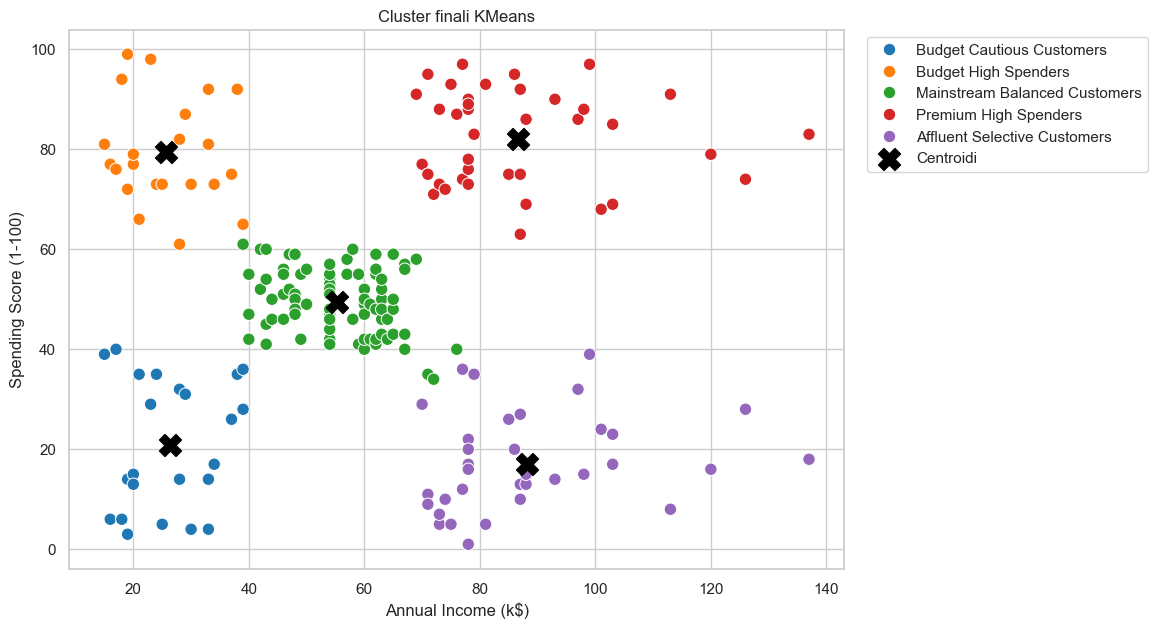

In [13]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=clustered_df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue=clustered_df["cluster"].map(segment_name_map),
    palette="tab10",
    s=80,
)
plt.scatter(
    cluster_centers_original[:, 0],
    cluster_centers_original[:, 1],
    c="black",
    marker="X",
    s=250,
    label="Centroidi",
)
plt.title("Cluster finali KMeans")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 6. Deployment

Implementiamo `segmenta_cliente(dati)`:

- usa lo scaler e il KMeans finale
- assegna il cliente al cluster piu' vicino
- restituisce il profilo del segmento e la strategia marketing consigliata

In [14]:
model_bundle = {
    "model": final_model,
    "scaler": scaler,
    "feature_columns": final_feature_columns,
    "segment_name_map": segment_name_map,
    "segment_profiles": segment_profiles.to_dict(orient="records"),
    "marketing_strategy_map": marketing_strategy_map,
    "cluster_centers_original": centers_df.to_dict(orient="records"),
}

model_path = ARTIFACTS_DIR / "mall_customer_segmentation_bundle.joblib"
joblib.dump(model_bundle, model_path)
print(model_path.resolve())

segment_profiles_by_id = {int(row["cluster"]): row for row in segment_profiles.to_dict(orient="records")}

def segmenta_cliente(dati):
    customer_frame = pd.DataFrame([dati])
    customer_features = customer_frame[final_feature_columns]
    customer_scaled = scaler.transform(customer_features)
    cluster_id = int(final_model.predict(customer_scaled)[0])
    distances = final_model.transform(customer_scaled)[0]
    closest_distance = float(distances[cluster_id])

    return {
        "cluster": cluster_id,
        "segment_name": segment_name_map[cluster_id],
        "distance_to_centroid": round(closest_distance, 4),
        "input_customer": dati,
        "segment_profile": segment_profiles_by_id[cluster_id],
        "marketing_strategy": marketing_strategy_map[segment_name_map[cluster_id]],
    }

example_customer = {
    "Annual Income (k$)": 88,
    "Spending Score (1-100)": 82,
}
segmenta_cliente(example_customer)

C:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\mall_customer_segmentation_bundle.joblib


{'cluster': 1,
 'segment_name': 'Premium High Spenders',
 'distance_to_centroid': 0.056,
 'input_customer': {'Annual Income (k$)': 88, 'Spending Score (1-100)': 82},
 'segment_profile': {'cluster': 1,
  'segment_name': 'Premium High Spenders',
  'n_customers': 39,
  'avg_age': 32.69230769230769,
  'avg_income': 86.53846153846153,
  'avg_spending_score': 82.12820512820512,
  'female_share': 0.5384615384615384,
  'marketing_strategy': 'VIP programs, early access to launches, premium upselling, concierge-style service.'},
 'marketing_strategy': 'VIP programs, early access to launches, premium upselling, concierge-style service.'}

In [15]:
final_business_summary = pd.DataFrame(
    [
        {
            "question": "Quanti segmenti naturali esistono?",
            "answer": f"{optimal_k} cluster",
            "evidence": f"Silhouette massima = {k_results['silhouette'].max():.4f} con k = {optimal_k}",
        },
        {
            "question": "Le metriche soddisfano il requisito?",
            "answer": "Si",
            "evidence": (
                f"KMeans: silhouette = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'silhouette'].iloc[0]:.4f}, "
                f"Calinski-Harabasz = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'calinski_harabasz'].iloc[0]:.2f}, "
                f"Davies-Bouldin = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'davies_bouldin'].iloc[0]:.4f}"
            ),
        },
        {
            "question": "Qual e' il modello finale?",
            "answer": "KMeans su Income + Spending Score",
            "evidence": "Eccellente separazione, interpretabilita' elevata e deployment semplice.",
        },
    ]
)
display(final_business_summary)

report_path = ROOT / "04_segmentazione_clienti_report.md"
report_text = f"""# Report - Segmentazione clienti

## Risposte
- Numero di segmenti naturali: {optimal_k}
- Modello finale: KMeans su Annual Income e Spending Score
- Silhouette Score = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'silhouette'].iloc[0]:.4f}
- Calinski-Harabasz = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'calinski_harabasz'].iloc[0]:.2f}
- Davies-Bouldin = {model_comparison.loc[model_comparison['algorithm']=='KMeans', 'davies_bouldin'].iloc[0]:.4f}

## Segmenti identificati
{segment_profiles[['segment_name', 'marketing_strategy']].to_string(index=False)}

## Conclusione
I dati mostrano 5 segmenti naturali molto interpretabili dal punto di vista marketing.
"""
report_path.write_text(report_text, encoding="utf-8")
print(report_path.resolve())

,question,answer,evidence
0,Quanti segmenti naturali esistono?,5 cluster,Silhouette massima = 0.5547 con k = 5
1,Le metriche soddisfano il requisito?,Si,"KMeans: silhouette = 0.5547, Calinski-Harabasz..."
2,Qual e' il modello finale?,KMeans su Income + Spending Score,"Eccellente separazione, interpretabilita' elev..."


C:\Users\samue\Desktop\Machine_Learning_exercises\04_segmentazione_clienti_report.md
